# Explainable Customer Churn Prediction

## 1. Model Evaluation

This notebook focuses on evaluating the selected machine learning
model using classification metrics, confusion matrix, ROC curve,
precision-recall curve, and error analysis.

In [43]:
import pickle

with open("/content/x_test_processed.pkl", "rb") as f:
    x_test_processed = pickle.load(f)

with open("/content/y_test.pkl", "rb") as f:
    y_test = pickle.load(f)

print(x_test_processed.shape)
print(y_test.shape)


(1409, 45)
(1409,)


In [44]:
with open("/content/logistic_regression_model.pkl", "rb") as f:
    model = pickle.load(f)

In [45]:
y_prob = model.predict_proba(x_test_processed)[:, 1]

In [46]:
threshold = 0.3
final_y_pred = (y_prob >= threshold).astype(int)

In [47]:
print(final_y_pred.shape)

(1409,)


In [48]:
from sklearn.metrics import confusion_matrix

final_cm=confusion_matrix(y_test, final_y_pred)
final_cm


array([[774, 261],
       [ 92, 282]])

In [49]:
from sklearn.metrics import roc_curve,roc_auc_score

In [50]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)


In [51]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8421349040274871


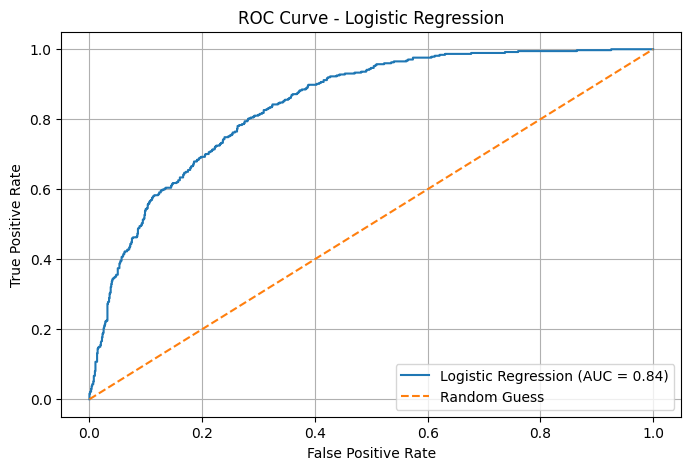

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid()
plt.show()

In [53]:
errors = y_test != final_y_pred
errors

,Churn
437,False
2280,True
2235,False
4460,True
3761,False
...,...
5143,False
4439,False
3857,False
4758,False


In [54]:
print("Total errors:", errors.sum())

Total errors: 353


In [55]:
false_positives = (y_test == 0) & (final_y_pred == 1)
false_positives.sum()


np.int64(261)

In [56]:
false_negatives = (y_test == 1) & (final_y_pred == 0)
false_negatives.sum()

np.int64(92)

In [57]:
import pandas as pd

df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(0)

df.drop("customerID", axis=1, inplace=True)

In [58]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

x_train, x_test, y_train_original, y_test_original = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [72]:
error_analysis = x_test.copy()
error_analysis["Actual"] = y_test.values

In [73]:
error_analysis["Predicted"] = final_y_pred

In [74]:
error_analysis["Churn_Probability"] = y_prob

In [75]:
error_analysis["Error"] = (
    error_analysis["Actual"] != error_analysis["Predicted"]
)

In [76]:
error_analysis[
    error_analysis["Error"] == True
].head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual,Predicted,Churn_Probability,Error
2280,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,0,1,0.683713,True
4460,Male,0,Yes,No,18,Yes,No,Fiber optic,No,No,...,No,Month-to-month,No,Electronic check,78.20,1468.75,0,1,0.401835,True
5748,Female,0,No,No,21,Yes,Yes,Fiber optic,No,Yes,...,Yes,Month-to-month,Yes,Credit card (automatic),99.85,1992.55,0,1,0.602978,True
3568,Female,0,No,No,21,Yes,No,Fiber optic,No,Yes,...,Yes,Month-to-month,Yes,Bank transfer (automatic),99.15,1956.40,0,1,0.447629,True
2136,Male,0,No,Yes,15,Yes,Yes,Fiber optic,No,Yes,...,No,Month-to-month,Yes,Electronic check,91.00,1430.05,0,1,0.636815,True
1838,Male,1,No,No,54,Yes,Yes,Fiber optic,No,Yes,...,Yes,Month-to-month,Yes,Electronic check,90.05,4931.80,0,1,0.444172,True
6979,Male,0,No,Yes,1,No,No phone service,DSL,No,No,...,No,Month-to-month,No,Mailed check,24.20,24.20,0,1,0.438108,True
2488,Male,0,No,No,31,Yes,No,DSL,No,No,...,No,Month-to-month,Yes,Electronic check,55.25,1715.65,1,0,0.184571,True
2519,Male,0,Yes,No,2,Yes,Yes,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,91.45,171.45,0,1,0.786595,True
5400,Female,0,No,No,33,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Bank transfer (automatic),70.40,2406.10,0,1,0.348196,True


In [77]:
error_analysis = x_test.copy()

error_analysis["Actual"] = y_test.values
error_analysis["Predicted"] = final_y_pred
error_analysis["Churn_Probability"] = y_prob

error_analysis["Error"] = (
    error_analysis["Actual"] != error_analysis["Predicted"]
)

In [78]:
false_negative_customers = error_analysis[
    (error_analysis["Actual"] == 1) &
    (error_analysis["Predicted"] == 0)
]

In [79]:
false_negative_customers[
    [
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Contract",
        "InternetService",
        "TechSupport",
        "OnlineSecurity",
        "PaymentMethod",
        "Actual",
        "Predicted",
        "Churn_Probability"
    ]
].head(10)

,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,TechSupport,OnlineSecurity,PaymentMethod,Actual,Predicted,Churn_Probability
2488,31,55.25,1715.65,Month-to-month,DSL,Yes,No,Electronic check,1,0,0.184571
5086,45,20.40,930.45,One year,No,No internet service,No internet service,Electronic check,1,0,0.029487
3408,4,50.70,151.30,Month-to-month,DSL,No,No,Credit card (automatic),1,0,0.259157
7011,4,60.40,272.15,Month-to-month,DSL,Yes,Yes,Mailed check,1,0,0.207053
3158,18,49.55,878.35,Month-to-month,DSL,No,No,Mailed check,1,0,0.285479
5968,12,74.05,872.65,One year,DSL,Yes,No,Mailed check,1,0,0.209067
1577,17,98.60,1704.95,One year,Fiber optic,Yes,No,Bank transfer (automatic),1,0,0.232930
2361,1,45.95,45.95,Month-to-month,DSL,No,No,Mailed check,1,0,0.295851
1014,18,57.45,990.85,Month-to-month,DSL,No,No,Electronic check,1,0,0.286137
6388,1,20.40,20.40,Month-to-month,No,No internet service,No internet service,Mailed check,1,0,0.189158


In [80]:
false_negative_customers.sort_values(
    "Churn_Probability",
    ascending=False
).head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual,Predicted,Churn_Probability,Error
4792,Female,1,Yes,No,65,Yes,Yes,Fiber optic,No,Yes,...,Yes,One year,Yes,Electronic check,106.25,6979.80,1,0,0.298403,True
2361,Female,0,No,Yes,1,Yes,No,DSL,No,No,...,No,Month-to-month,No,Mailed check,45.95,45.95,1,0,0.295851,True
3216,Female,0,Yes,Yes,1,Yes,No,DSL,No,No,...,No,Month-to-month,No,Mailed check,50.45,50.45,1,0,0.294060,True
402,Male,0,Yes,Yes,69,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Credit card (automatic),99.45,7007.60,1,0,0.290714,True
1014,Male,0,Yes,Yes,18,Yes,No,DSL,No,No,...,Yes,Month-to-month,No,Electronic check,57.45,990.85,1,0,0.286137,True
3158,Male,0,Yes,No,18,Yes,No,DSL,No,No,...,No,Month-to-month,Yes,Mailed check,49.55,878.35,1,0,0.285479,True
5006,Female,0,No,No,15,Yes,Yes,DSL,Yes,No,...,No,Month-to-month,Yes,Mailed check,55.70,899.80,1,0,0.284346,True
6972,Female,1,No,No,56,Yes,Yes,Fiber optic,No,Yes,...,Yes,One year,Yes,Electronic check,111.95,6418.90,1,0,0.281730,True
6207,Male,1,No,No,46,Yes,No,Fiber optic,Yes,No,...,Yes,Month-to-month,No,Electronic check,85.00,3969.40,1,0,0.280174,True
674,Male,1,No,No,52,No,No phone service,DSL,No,Yes,...,Yes,Month-to-month,Yes,Electronic check,49.15,2550.90,1,0,0.277726,True


In [81]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

final_accuracy = accuracy_score(y_test, final_y_pred)
final_precision = precision_score(y_test, final_y_pred)
final_recall = recall_score(y_test, final_y_pred)
final_f1 = f1_score(y_test, final_y_pred)
final_roc_auc = roc_auc_score(y_test, y_prob)

print("Final Accuracy:", round(final_accuracy, 3))
print("Final Precision:", round(final_precision, 3))
print("Final Recall:", round(final_recall, 3))
print("Final F1-score:", round(final_f1, 3))
print("Final ROC-AUC:", round(final_roc_auc, 3))

Final Accuracy: 0.749
Final Precision: 0.519
Final Recall: 0.754
Final F1-score: 0.615
Final ROC-AUC: 0.842


In [82]:
final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Score": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_roc_auc
    ]
})

final_results

,Metric,Score
0,Accuracy,0.749468
1,Precision,0.519337
2,Recall,0.754011
3,F1-score,0.615049
4,ROC-AUC,0.842135


In [83]:
print("Final Confusion Matrix:")
print(final_cm)

Final Confusion Matrix:
[[774 261]
 [ 92 282]]


## Final Evaluation Summary

The Logistic Regression model was selected as the final model based on its
better performance compared with the Random Forest model in the current
experimental setup.

The final classification threshold was set to 0.3 instead of the default
0.5 to improve the detection of customers likely to churn.

At the selected threshold, the model achieved higher recall for the churn
class, reducing false negatives from 165 at the 0.5 threshold to 92 at the
0.3 threshold. However, this also increased the number of false positives.

The final confusion matrix contains 774 true negatives, 261 false positives,
92 false negatives, and 282 true positives.

This demonstrates the trade-off between identifying more potential churners
and generating more false alarms. The selected threshold prioritizes recall
because missing a customer who is likely to churn can be more costly for a
business than incorrectly identifying a customer as being at risk.

The model achieved a ROC-AUC of approximately 0.84, indicating good
discrimination between churned and non-churned customers.

The model's performance should be interpreted in the context of the current
dataset, preprocessing approach, model configuration, and threshold choice.